In [9]:
import pandas as pd

data = pd.read_csv('./data/clean/RO_data_aggregated.csv')
data["Date"] = pd.to_datetime(data["Date"])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Date                              261 non-null    datetime64[us]
 1   ALIMENTATION - Débit (m3/h)       254 non-null    float64       
 2   ALIMENTATION - Débit (m3/h) PX    253 non-null    float64       
 3   ALIMENTATION - Pression HP (bar)  256 non-null    float64       
 4   PERMEAT - Conductivité (µS/cm)    255 non-null    float64       
 5   PERMEAT - Débit (m3/h)            256 non-null    float64       
 6   PERMEAT - Pression Sortie (bar)   256 non-null    float64       
 7   delta P                           255 non-null    float64       
 8   Performance Débit                 254 non-null    float64       
dtypes: datetime64[us](1), float64(8)
memory usage: 18.5 KB


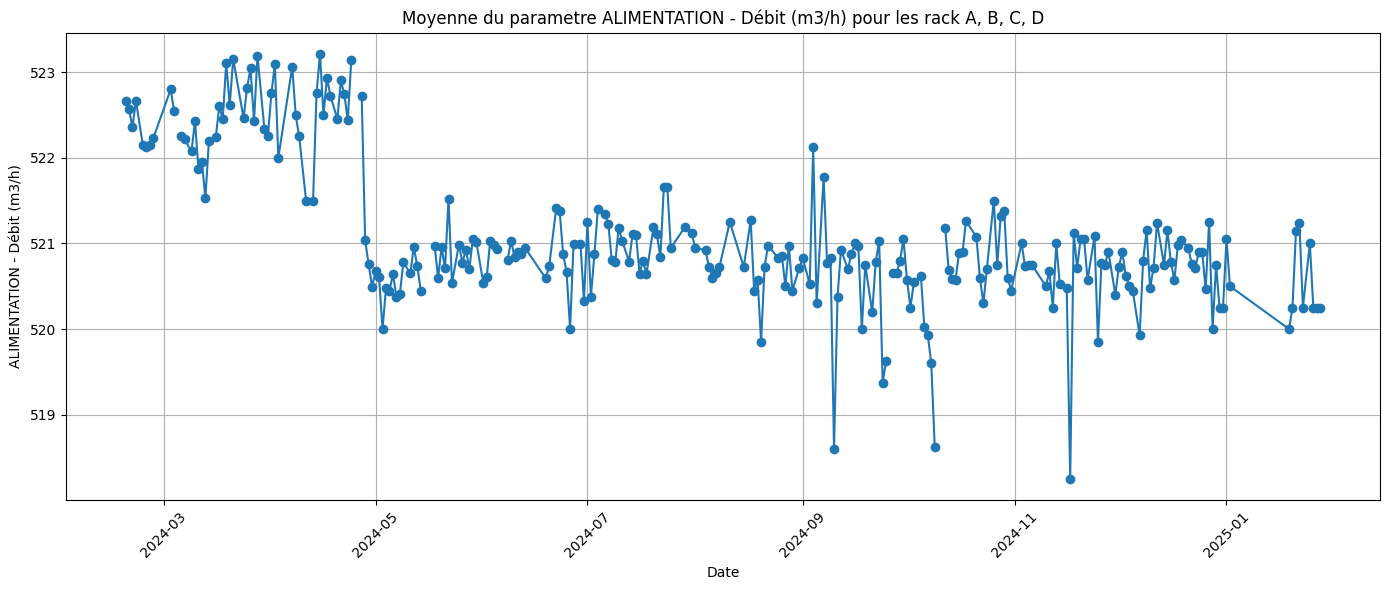

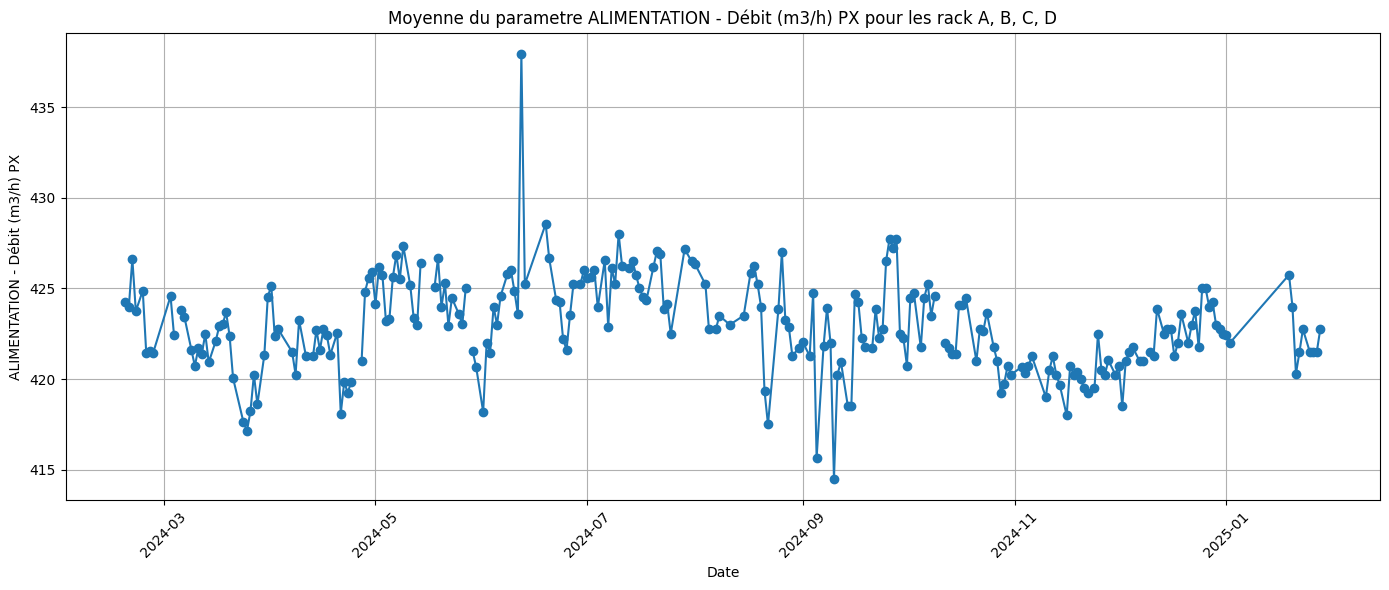

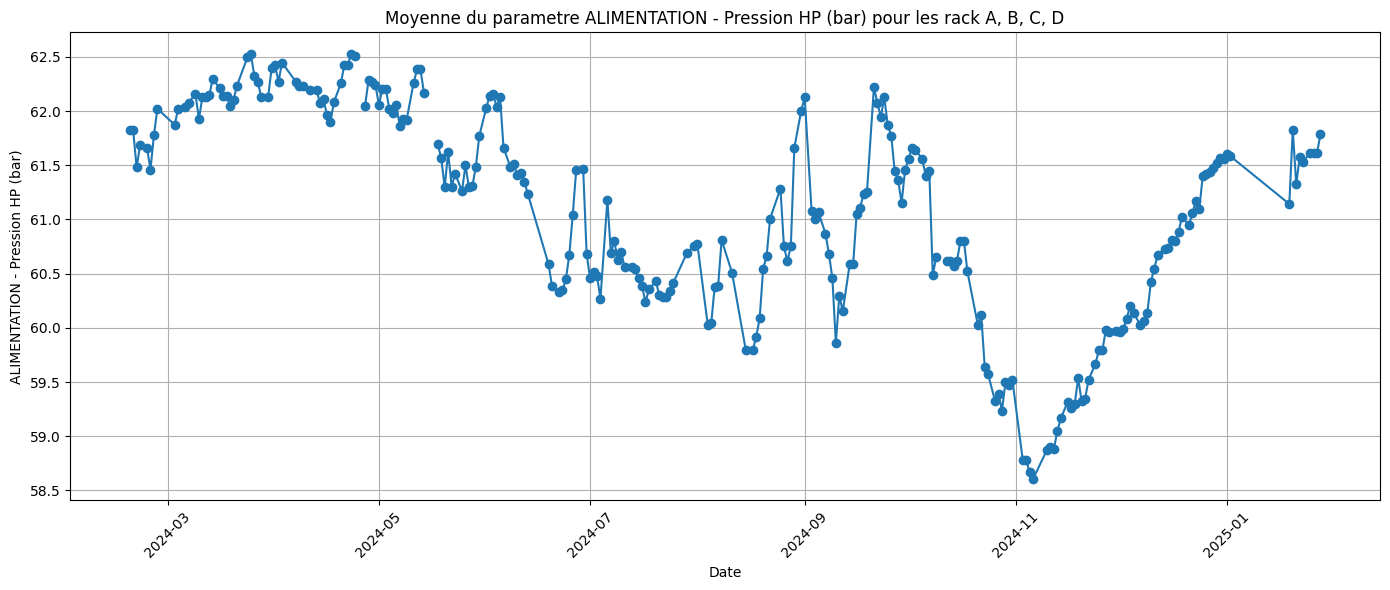

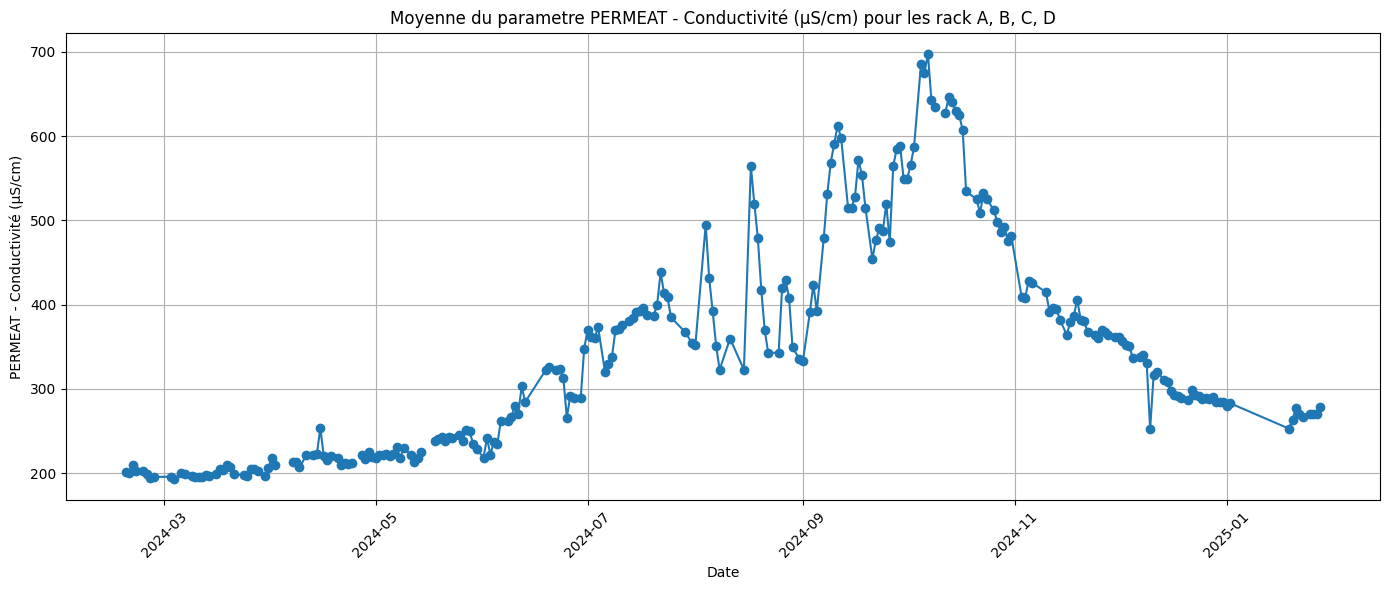

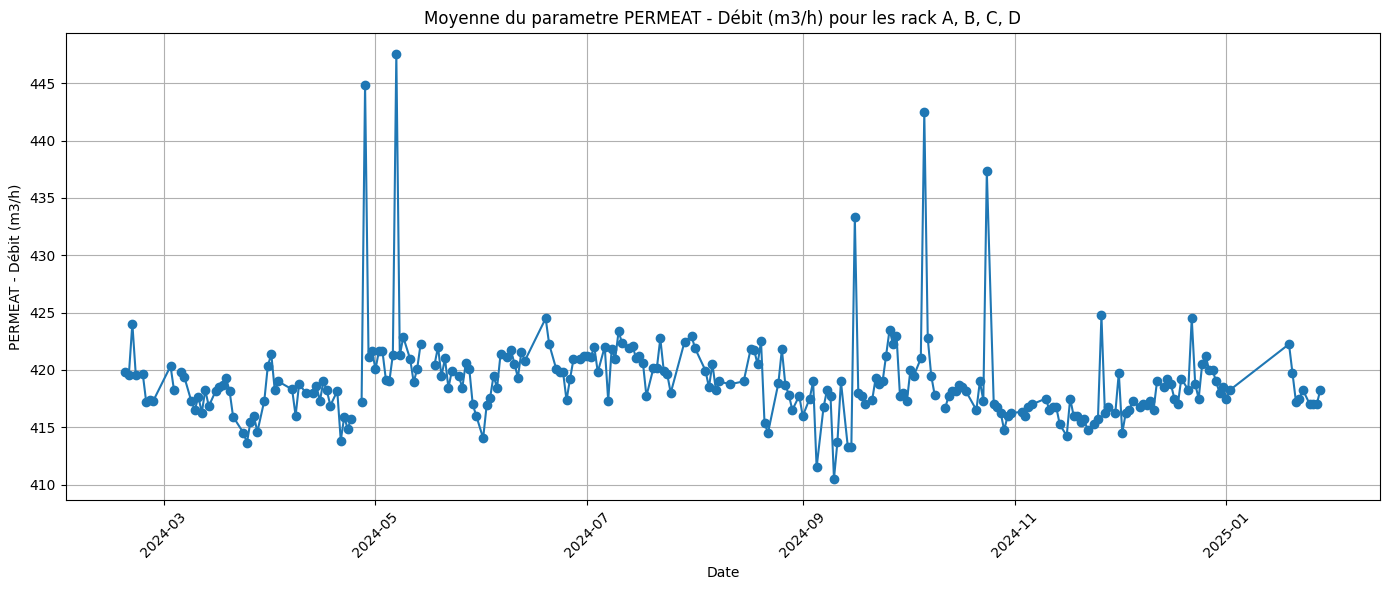

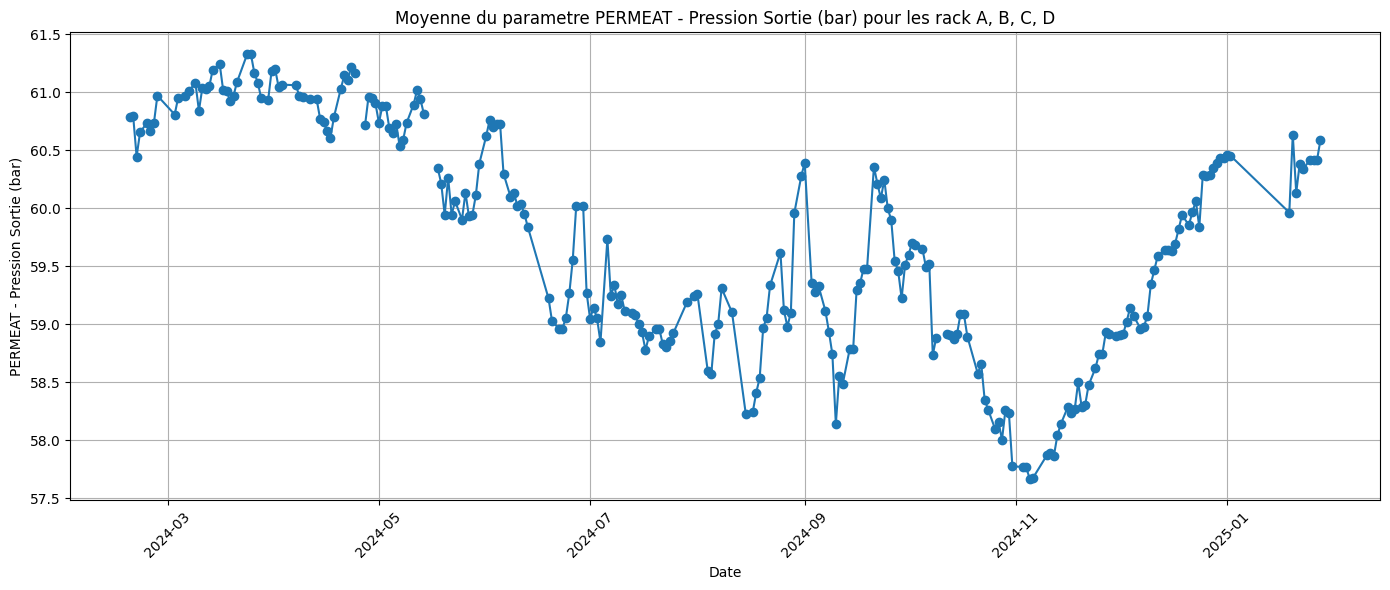

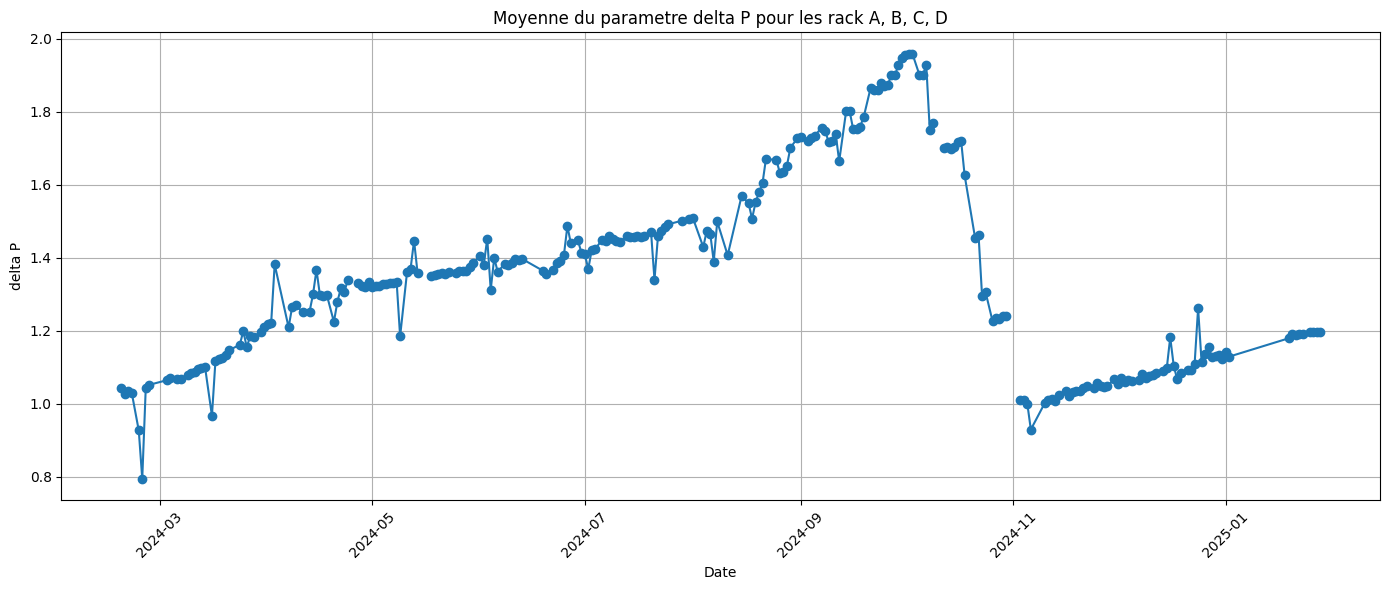

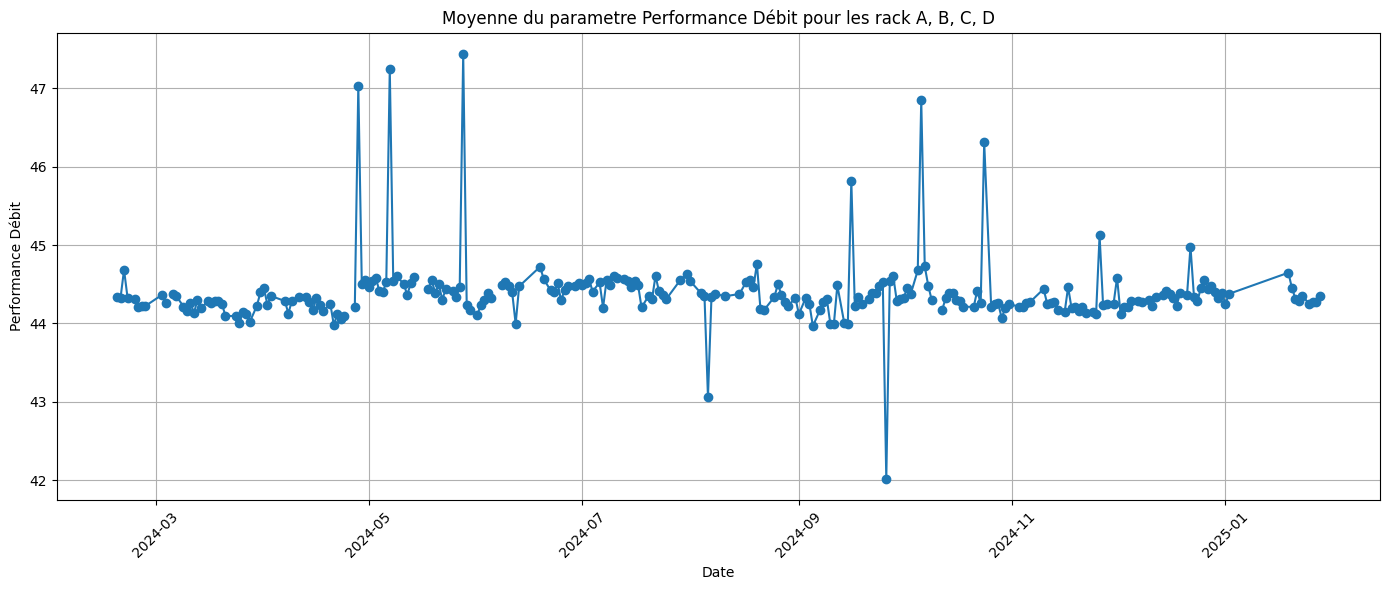

In [10]:
# build plots for rack A
import matplotlib.pyplot as plt
import seaborn as sns

for col in data.columns:
    if col != 'Date':
        plt.figure(figsize=(14, 6))
        plt.plot(data['Date'], data[col], marker='o')
        plt.title(f'Moyenne du parametre {col} pour les rack A, B, C, D')
        plt.xlabel('Date')
        plt.ylabel(col)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.grid()
        # replace / in name of the columns
        col_name = col.replace('/', '_')
        plt.savefig(f'./results/RO_eda/plots/{col_name}_rack_ABCD.png')
        plt.show()

In [29]:
import seaborn as sns
import numpy as np
corr = data.drop(columns = "Date").corr()

# mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(24,20))

sns.heatmap(
    corr * 100,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=1.5,
    annot_kws={"size": 15},
    cbar_kws={"shrink": 0.9}
)
plt.xticks(fontsize=12, rotation=45, ha="right")
plt.yticks(fontsize=12, rotation=0)
plt.title("Correlation Heatmap", fontsize=16)
plt.savefig('./results/RO_eda/plots/RO_data_correlation_heatmap.png')
plt.close()

In [47]:
# caclulate the descriptive statistics
stat_desc = data.drop(columns="Date").describe()

# change the index and save to excel
index_french = {
    'count': 'Nombre de valeurs',
    'mean': 'Moyenne',
    'std': 'Ecart-type',
    'min': 'Minimum',
    '25%': '1er quartile',
    '50%': 'Médiane',
    '75%': '3ème quartile',
    'max': 'Maximum'
}

stat_desc.rename(index=index_french, inplace=True)
stat_desc.to_excel("./results/RO_eda/tables/RO_aggregated_stats.xlsx")

In [30]:
quality_data = pd.read_excel("./data/clean/Corso_données_journaliere.xlsx")
quality_data.index = pd.to_datetime(quality_data["DATE"])
quality_data

,DATE,pH_BC,Température_BC,Conductivité_BC,TDS_BC,Turbidité_BC,Ph_O_DE_A,Température_O_DE_A,Conductivité_O_DE_A,TDS_O_DE_A,...,Température_O_RO,Conductivité_O_RO,TDS_O_RO,Turbidité_O_RO,Ph_O_EX,Température_O_EX,Conductivité_O_EX,TDS_O_EX,Chlore libre_O_EX,Turbidité_O_EX
DATE,,,,,,,,,,,,,,,,,,,,,
2024-01-01,2024-01-01,8.260000,16.833333,55.033333,33.020000,0.403333,8.210000,16.966667,55.033333,33.02,...,18.033333,243.000000,121.500000,0.01,7.040000,18.800000,289.000000,144.500000,1.10,0.010000
2024-01-02,2024-01-02,8.246667,16.300000,55.000000,33.000000,0.973333,8.200000,16.533333,55.000000,33.00,...,NaN,NaN,NaN,NaN,6.973333,18.266667,285.333333,142.666667,1.00,0.010000
2024-01-03,2024-01-03,8.226667,17.066667,54.700000,32.820000,0.930000,8.163333,17.500000,54.833333,32.90,...,17.450000,214.800000,107.400000,0.01,6.943333,18.300000,267.666667,133.500000,1.00,0.010000
2024-01-04,2024-01-04,8.206667,16.933333,54.933333,32.960000,0.326667,8.186667,16.500000,55.066667,33.04,...,17.000000,216.766667,108.383333,0.01,7.020000,17.466667,317.666667,158.833333,1.00,0.010000
2024-01-05,2024-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27,2025-01-27,8.140000,17.933333,55.566667,38.896667,0.370000,8.106667,17.066667,NaN,NaN,...,17.066667,281.666667,154.916667,0.00,8.213333,17.266667,448.333333,246.583333,1.00,0.140000
2025-01-28,2025-01-28,8.203333,18.000000,55.500000,38.850000,2.596667,8.163333,17.133333,NaN,NaN,...,17.400000,275.333333,151.433333,0.00,8.310000,17.366667,395.000000,217.250000,1.00,0.033333
2025-01-29,2025-01-29,8.170000,17.200000,NaN,NaN,0.620000,8.120000,16.510000,NaN,NaN,...,16.800000,280.000000,154.000000,0.00,8.440000,17.700000,417.000000,229.350000,1.00,0.000000


In [31]:
# join the two dataframes on the date index
merged_data = data.set_index("Date").join(quality_data, how='inner')
merged_data

,ALIMENTATION - Débit (m3/h),ALIMENTATION - Débit (m3/h) PX,ALIMENTATION - Pression HP (bar),PERMEAT - Conductivité (µS/cm),PERMEAT - Débit (m3/h),PERMEAT - Pression Sortie (bar),delta P,Performance Débit,DATE,pH_BC,...,Température_O_RO,Conductivité_O_RO,TDS_O_RO,Turbidité_O_RO,Ph_O_EX,Température_O_EX,Conductivité_O_EX,TDS_O_EX,Chlore libre_O_EX,Turbidité_O_EX
Date,,,,,,,,,,,,,,,,,,,,,
2024-02-19,522.6700,424.2750,61.8275,201.250,419.8075,60.7850,1.0425,44.332827,2024-02-19,8.160000,...,17.200000,193.133333,96.566667,0.0,7.340000,17.533333,278.666667,139.333333,1.040000,0.000000
2024-02-20,522.5700,423.9950,61.8225,200.175,419.5825,60.7950,1.0275,44.326824,2024-02-20,8.166667,...,17.100000,190.833333,95.433333,0.0,7.223333,17.300000,280.666667,140.333333,1.010000,0.000000
2024-02-21,522.3600,426.6300,61.4800,209.500,424.0400,60.4450,1.0350,44.683331,2024-02-21,8.160000,...,17.266667,201.900000,100.966667,0.0,7.243333,17.566667,287.666667,143.833333,0.850000,0.000000
2024-02-22,522.6675,423.7475,61.6850,202.900,419.5400,60.6550,1.0300,44.329343,2024-02-22,8.193333,...,17.500000,198.966667,99.500000,0.0,7.213333,17.933333,289.666667,159.350000,0.970000,0.000000
2024-02-24,522.1450,424.8750,61.6625,202.750,419.6500,60.7350,0.9275,44.312912,2024-02-24,8.200000,...,16.500000,196.600000,101.716667,0.0,7.340000,17.133333,291.666667,160.433333,1.060000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-23,520.2500,422.7500,61.5325,267.000,418.2500,60.3400,1.1925,44.353452,2025-01-23,8.086667,...,16.966667,333.000000,183.150000,0.0,8.430000,17.366667,396.333333,217.983333,1.000000,0.083333
2025-01-25,521.0000,421.5000,61.6125,270.750,417.0000,60.4150,1.1975,44.244225,2025-01-25,8.123333,...,17.166667,298.666667,164.266667,0.0,8.386667,17.266667,430.333333,236.683333,1.066667,0.010000
2025-01-26,520.2500,421.5000,61.6125,270.750,417.0000,60.4150,1.1975,44.279352,2025-01-26,8.170000,...,16.966667,285.333333,156.933333,0.0,8.363333,17.466667,403.000000,221.650000,1.000000,0.086667


In [ ]:
# merged_data.to_csv("./data/ML/RO_avg_pressure_modeling.csv")

In [44]:
corr = merged_data.drop(columns="DATE").iloc[:, :13].corr()

# mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(28, 25))
sns.heatmap(corr * 100, mask=mask, annot=True, cmap='coolwarm',     linewidths=1.5,
    annot_kws={"size": 15},
    cbar_kws={"shrink": 0.9})

plt.xticks(fontsize=14, rotation=45, ha="right")
plt.yticks(fontsize=14, rotation=0)

plt.savefig('./results/RO_eda/plots/RO_quality_correlation_heatmap.png')
plt.close()